downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Accuracy : 89.17%

 classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      0.67      0.80         3
           2       0.67      0.67      0.67         3
           3       0.43      1.00      0.60         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      0.33      0.50         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1

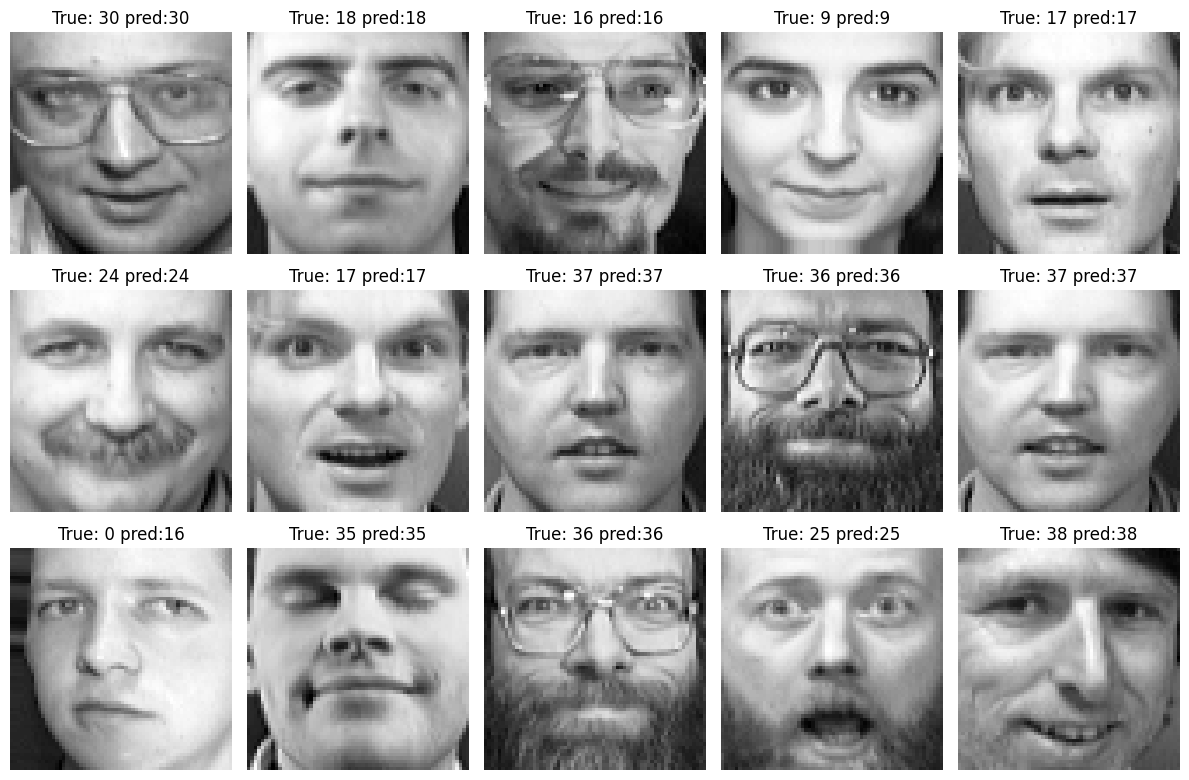

In [1]:
  import numpy as np
  from sklearn.datasets import fetch_olivetti_faces
  from sklearn.model_selection import train_test_split , cross_val_score
  from sklearn.naive_bayes import GaussianNB
  from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
  import matplotlib.pyplot as plt

  data = fetch_olivetti_faces(shuffle=True , random_state=42)
  X = data.data
  y = data.target

  X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=42 , stratify=y)

  gnb = GaussianNB()
  gnb.fit(X_train , y_train)

  y_pred = gnb.predict(X_test)

  accuracy = accuracy_score(y_test , y_pred)
  print(f'Accuracy : {accuracy*100:.2f}%')

  print("\n classification Report:")
  print(classification_report(y_test,y_pred,zero_division=1))

  print('\nConfusion Matrix : ')
  print(confusion_matrix(y_test , y_pred))

  fig,axes = plt.subplots(3,5 , figsize=(12,8))
  for ax , image , label , prediction in zip(axes.ravel() , X_test , y_test , y_pred):
    ax.imshow(image.reshape(64,64) , cmap=plt.cm.gray)
    ax.set_title(f"True: {label} pred:{prediction}")
    ax.axis('off')

  plt.tight_layout()
  plt.show()



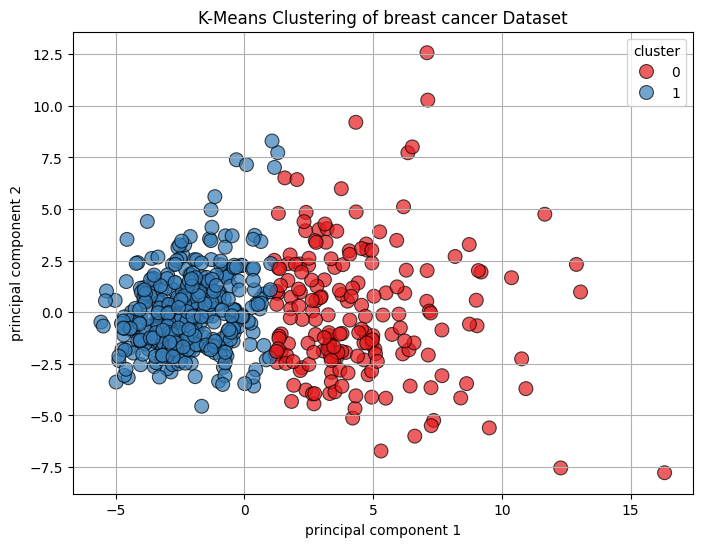

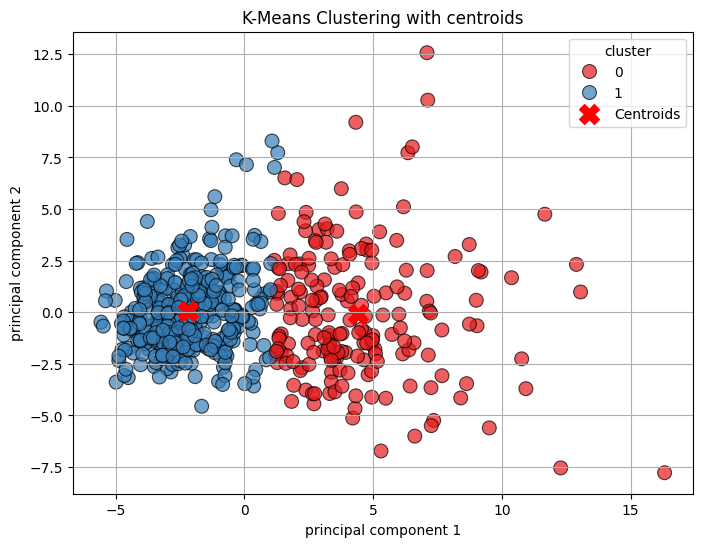

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix,classification_report

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters = 2 , random_state = 42)
y_kmeans = kmeans.fit_predict(X_scaled)

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns = ['PC1', 'PC2'])
df['Cluster'] = y_kmeans
df['True Label'] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='PC1', y='PC2', hue='Cluster',palette='Set1' , s = 100 , edgecolor = 'black' , alpha=0.7)
plt.title('K-Means Clustering of breast cancer Dataset')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(title = "cluster")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='PC1', y='PC2', hue='Cluster',palette='Set1' , s = 100 , edgecolor = 'black' , alpha=0.7)
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200,marker = 'X', label='Centroids')
plt.title('K-Means Clustering with centroids')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(title = "cluster")
plt.grid(True)
plt.show()

